### Libraries

In [1]:
import numpy as np
import numpy.typing as npt
import pandas as pd
import pickle
import time
import itertools
from collections import Counter
import json

import matplotlib.pyplot as plt
import matplotlib.pylab as plt
import matplotlib.cm as cm
import seaborn as sns


from tqdm import tqdm

from sklearn.feature_selection import (mutual_info_classif, chi2, SequentialFeatureSelector)
from sklearn.preprocessing import (LabelEncoder, MinMaxScaler, StandardScaler, KBinsDiscretizer)
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_recall_curve, roc_curve, 
                             f1_score, confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import MDS

import gurobipy as gp
from gurobipy import GRB

#import shap
from boruta import BorutaPy
from sklearn.inspection import permutation_importance
import xgboost as xgb
from xgboost import XGBClassifier

from braket.ahs.atom_arrangement import AtomArrangement
from braket.ahs.driving_field import DrivingField
from braket.ahs.local_detuning import LocalDetuning
from braket.ahs.analog_hamiltonian_simulation import AnalogHamiltonianSimulation
from braket.timings.time_series import TimeSeries
from braket.devices import LocalSimulator

# Initialize simulator
simulator = LocalSimulator("braket_ahs")


### Self functions

In [2]:
from Data_functions import (prepare_train_test_simple, compute_importance_and_redundancy_simple, Boruta_selection, 
                            Importance_selection,MI_complete_det)

from QFS_Auxiliar_functions import QFS_NA_Solver, generate_sets_from_density, normalize_matrix, export_results_csv, load_results_csv

from Prediction_and_results import (sort_by_rydberg_dens, plot_overlap_from_csv, plot_metrics_combined, 
                                    Metrics_Results_Comparison_subsets, plot_metrics_combined_two_csvs, plot_metrics_combined_two_csvs_2)

### Import CSV and pre-processing the data (Discretizing and creating Mutual Info matrix)

In [3]:
#df = pd.read_csv("Datasets/adult_combined_clean.csv")  
#label = 'ADULT'
#target = 'income'

df = pd.read_csv("Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df.drop("customerID", axis=1)
label = 'CHURN'
target = 'Churn'

#df = pd.read_csv("Datasets/Bank_Marketing_Dataset__Clean_.csv")
#df = df.drop("ID", axis=1)
#label = 'BANK'
#target = 'y'

X_df, X_train, y_train, X_test, y_test, feature_names = prepare_train_test_simple(
    df, target=target, test_size=0.15, random_state=42, stratify=True, encode_objects=True)

MI_x_y, MI_x_x, mi_df, feature_names = compute_importance_and_redundancy_simple(X_train[feature_names], y_train)


In [4]:
X_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660


#### Visualizing Mutual Info Matrix

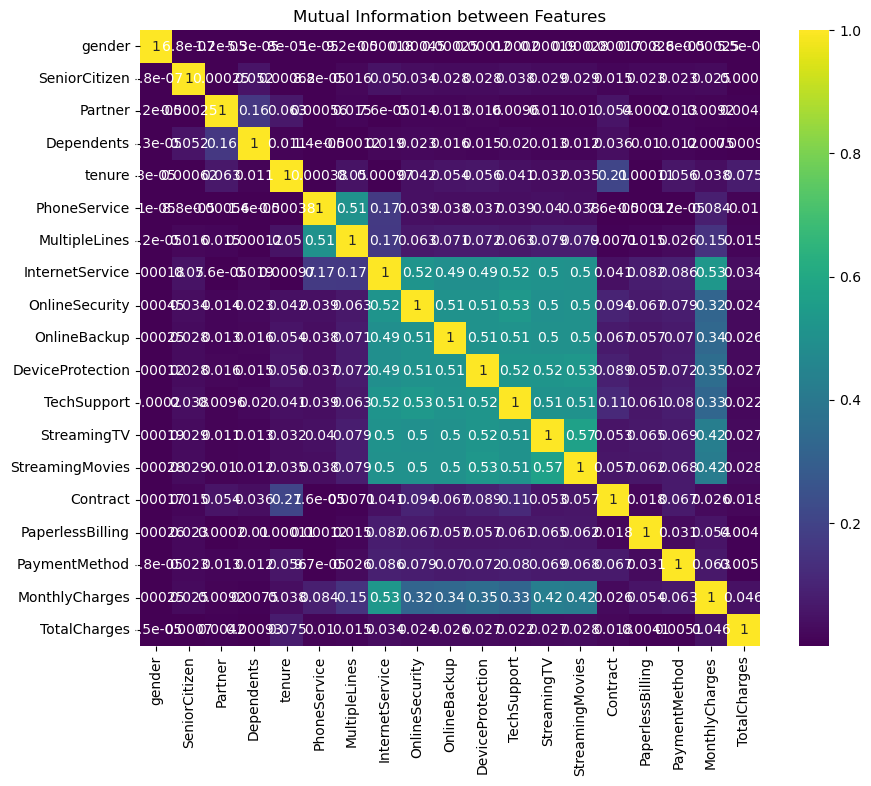

In [5]:
# Data Frame for representation
mi_xx_df = pd.DataFrame(MI_x_x, index=feature_names, columns=feature_names)

# Visualize the mutual information matrix
plt.figure(figsize=(10, 8))
sns.heatmap(mi_xx_df, annot=True, cmap='viridis')
plt.title("Mutual Information between Features")
plt.show()

### Clasical Feature selection

In [6]:
boruta_features = Boruta_selection(X_train, y_train)

Boruta's Selected Features: ['SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Boruta's Rejected Features: ['gender', 'Partner', 'DeviceProtection', 'StreamingTV']


In [7]:
importance_df, Imp_features_rank = Importance_selection(X_train, y_train)

In [8]:
importance_df

,Feature,Importance
14,Contract,0.385926
7,InternetService,0.170900
8,OnlineSecurity,0.064111
11,TechSupport,0.053286
13,StreamingMovies,0.031113
4,tenure,0.028424
15,PaperlessBilling,0.025943
5,PhoneService,0.024367
16,PaymentMethod,0.023500
6,MultipleLines,0.021792


### Quantum Feature Selection

Rydberg Radius(um) for selected drivings: 7.518864002388037
Computing arrangement...
Iter  d_min      d_max      min_radius     mean_error  
43    16.1189    47.2755    5.3588         0.289775    
44    16.2189    47.4755    5.3326         0.285383    
45    16.3189    47.6755    5.3332         0.287257    
46    16.4189    47.8755    5.3721         0.287160    
47    16.5189    48.0755    5.4593         0.285994    
48    16.6189    48.2755    5.5052         0.286086    
49    16.7189    48.4755    5.5457         0.286133    
50    16.8189    48.6755    5.5925         0.286153    
51    16.9189    48.8755    5.4730         0.289011    
52    17.0189    49.0755    5.3249         0.287000    
53    17.1189    49.2755    5.3452         0.287001    
54    17.2189    49.4755    5.3718         0.287074    
55    17.3189    49.6755    5.3985         0.287138    
56    17.4189    49.8755    5.4163         0.287689    
57    17.5189    50.0755    5.4493         0.287760    
58    17.6189    50

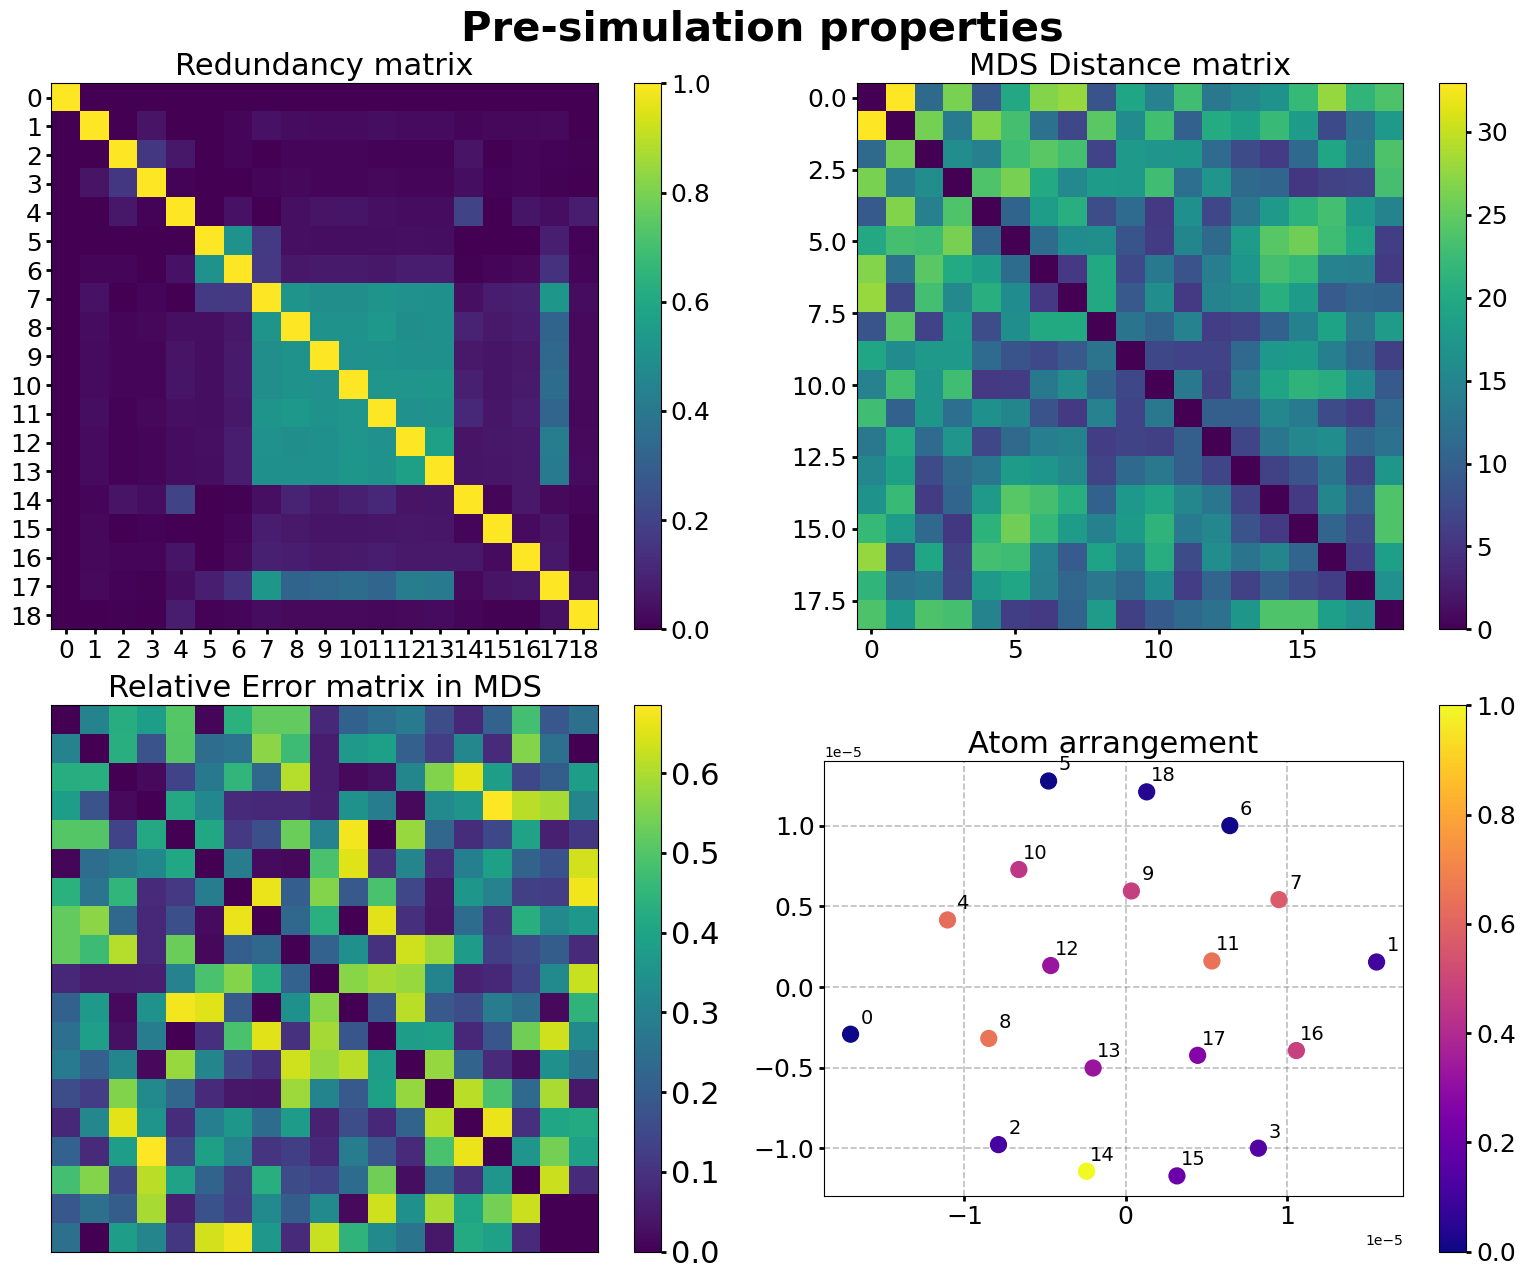

Performing simulation...


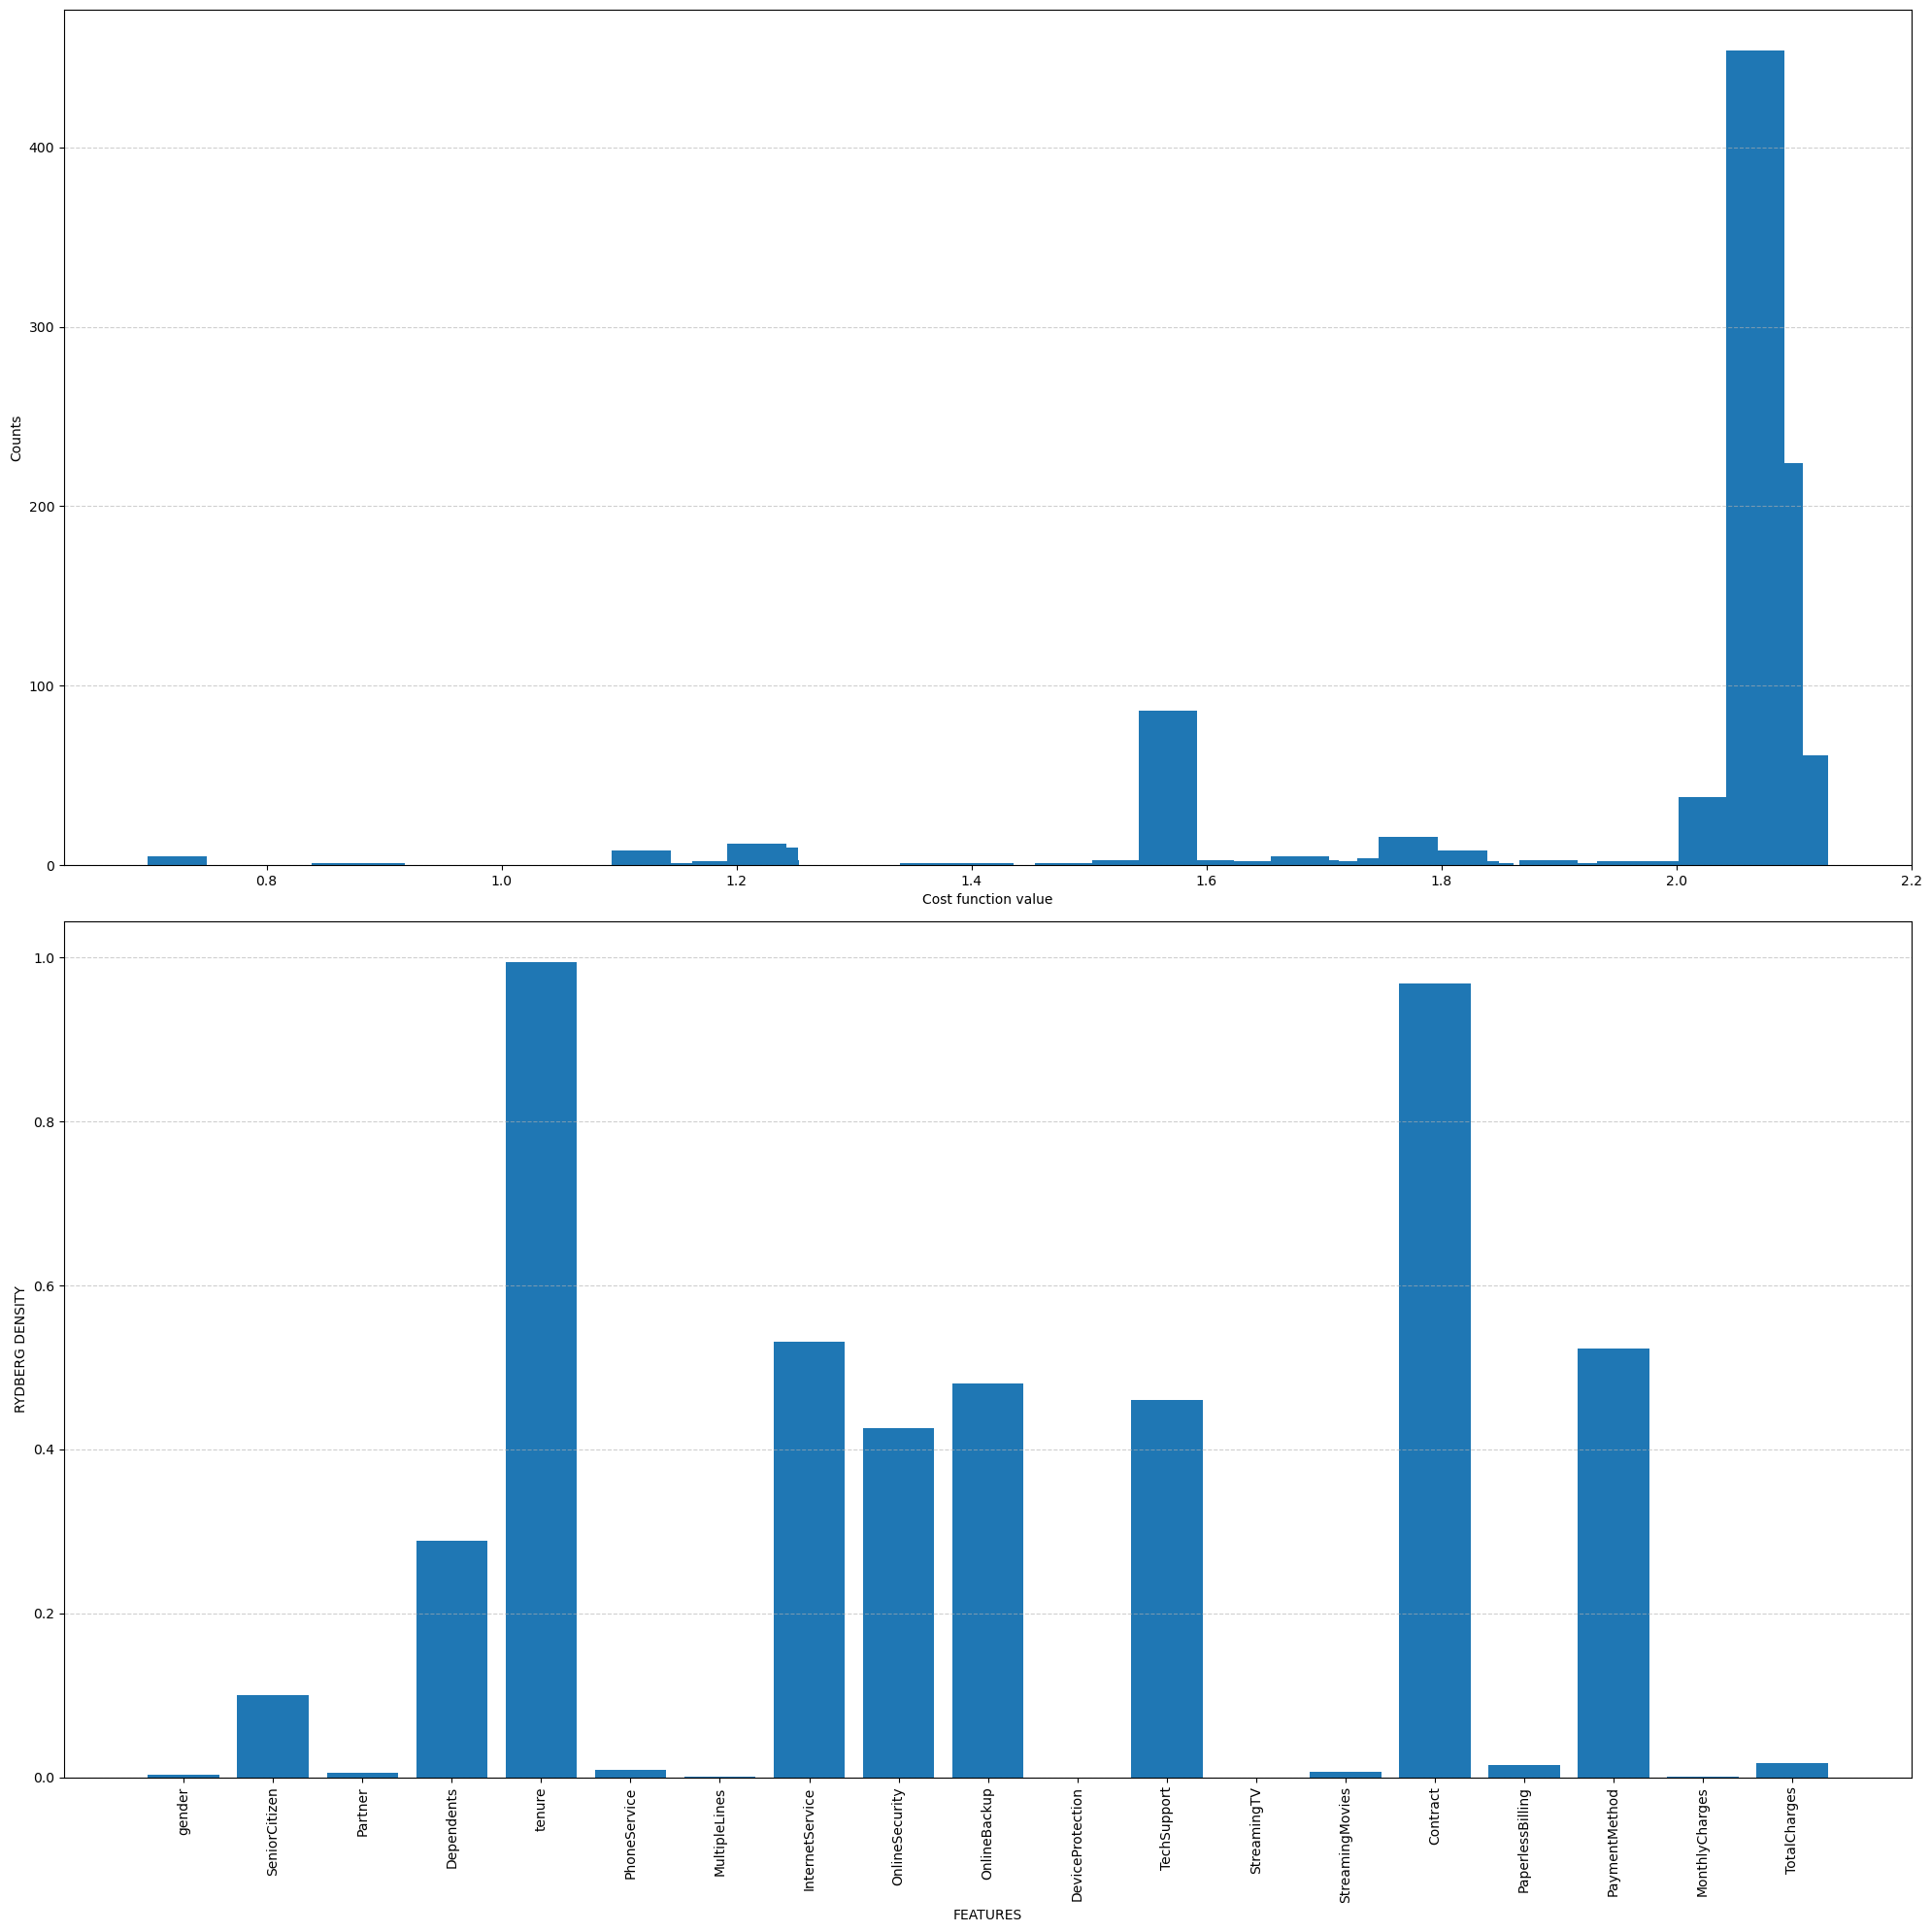

✅ Resultados exportados en Results/CHURN/QFS_Sim_Result_CHURN.csv


In [6]:
shots = 10000
t = 4
E_dist_fraction = 0.1

Cost_f, Counts, bit_list, avg_density  = QFS_NA_Solver(MI_x_y, MI_x_x, feature_names, label, E_dist_fraction, shots, t)
export_results_csv(Cost_f, Counts, bit_list, avg_density, f"Results/{label}/QFS_Sim_Result_{label}")


### Here we can load already existing results

In [10]:
#Cost_f, Counts, bit_list, avg_density = load_results_csv(f"Results/{label}/QFS_Sim_Result_{label}")
#print(avg_density)

# Prepare Feature sets and predictive models

### Create Best subsets with Redundancy

In [10]:
R_ij = normalize_matrix(MI_x_x)

alt_sets, best_sets = generate_sets_from_density(avg_density, R_ij, feature_names, max_sets=4, redundancy_threshold=0.5)


### Comparison Metrics for all NVAR (XGBoost)

In [11]:
save_path = f'Results/{label}/Metrics_comparison_{label}_subsets.csv'
model = 'xgb'

metrics_dict = Metrics_Results_Comparison_subsets(X_train, X_test, y_train, y_test, boruta_features, 
                            Imp_features_rank, best_sets, model, save_path)

Computing predictions for Boruta Features...
Computing predictions for Importance Ranking Features...


100%|███████████████████████████████████████████| 19/19 [03:22<00:00, 10.66s/it]


Computing predictions for Quantum Features...


100%|███████████████████████████████████████████| 19/19 [03:28<00:00, 10.95s/it]

✅ DATA STORED IN Results/CHURN/Metrics_comparison_CHURN_subsets.csv


In [13]:
#path = f"Results/PLOT_metrics_comparison_{label}_subsets.png"
#plot_metrics_combined(metrics_dict, path)

### Testing with Random Forest model

In [12]:
save_path = f'Results/{label}/Metrics_comparison_{label}_subsets_RF.csv'
model = 'rf'

metrics_dict = Metrics_Results_Comparison_subsets(X_train, X_test, y_train, y_test, boruta_features, 
                            Imp_features_rank, best_sets, model, save_path)

Computing predictions for Boruta Features...
Computing predictions for Importance Ranking Features...


100%|███████████████████████████████████████████| 19/19 [09:22<00:00, 29.61s/it]


Computing predictions for Quantum Features...


100%|███████████████████████████████████████████| 19/19 [10:29<00:00, 33.14s/it]

✅ DATA STORED IN Results/CHURN/Metrics_comparison_CHURN_subsets_RF.csv


In [15]:
#path = f"Results/PLOT_metrics_comparison_{label}_subsets_RF.png"
#plot_metrics_combined(metrics_dict, path)

### Comparing XGBoost and Random Forest performance

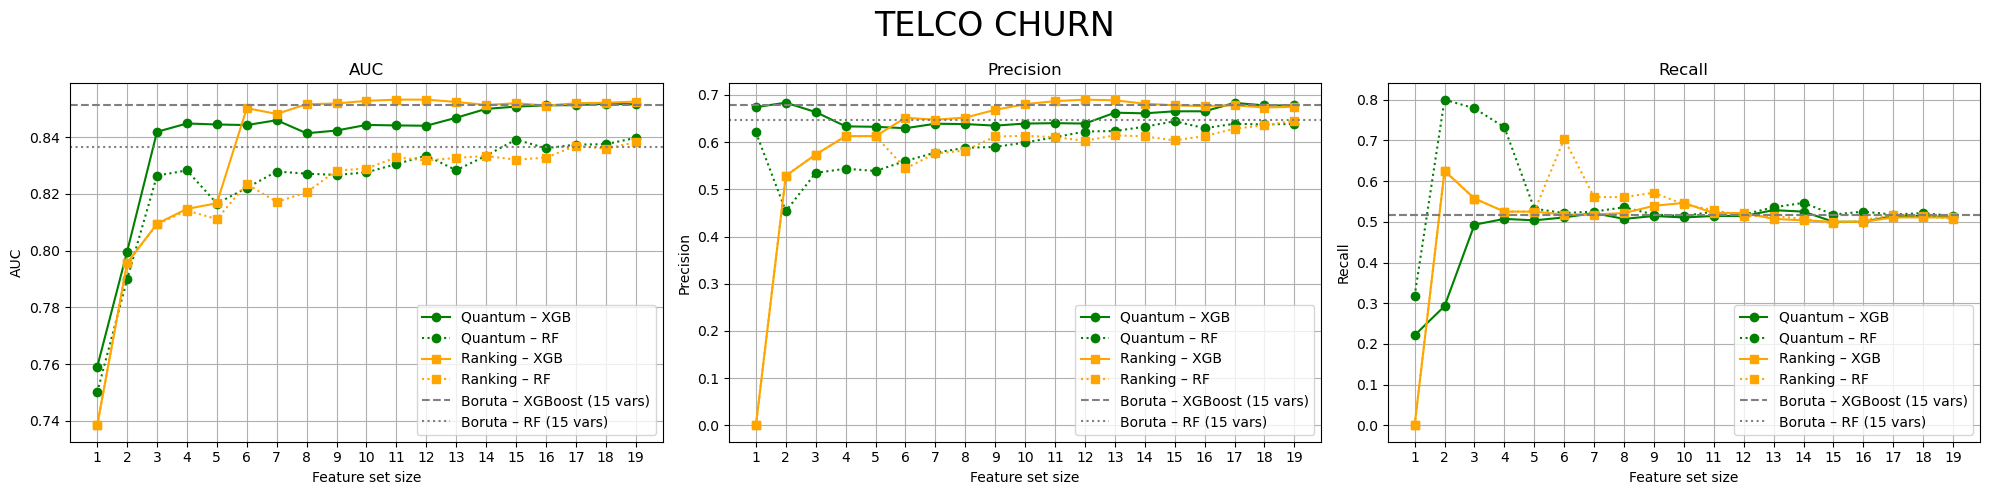

✅ PLOT STORED IN Results/CHURN/PLOT_Metrics_comparison_CHURN_subsets_XGB_vs_RF.png


'Results/CHURN/PLOT_Metrics_comparison_CHURN_subsets_XGB_vs_RF.png'

In [13]:
label = 'CHURN'

plot_metrics_combined_two_csvs(
    path_dir=f"Results/{label}",
    title = 'TELCO CHURN',
    csv_xgb=f"Metrics_comparison_{label}_subsets.csv",
    csv_rf=f"Metrics_comparison_{label}_subsets_RF.csv",
    dataset_label=label)


## FINAL PLOTS

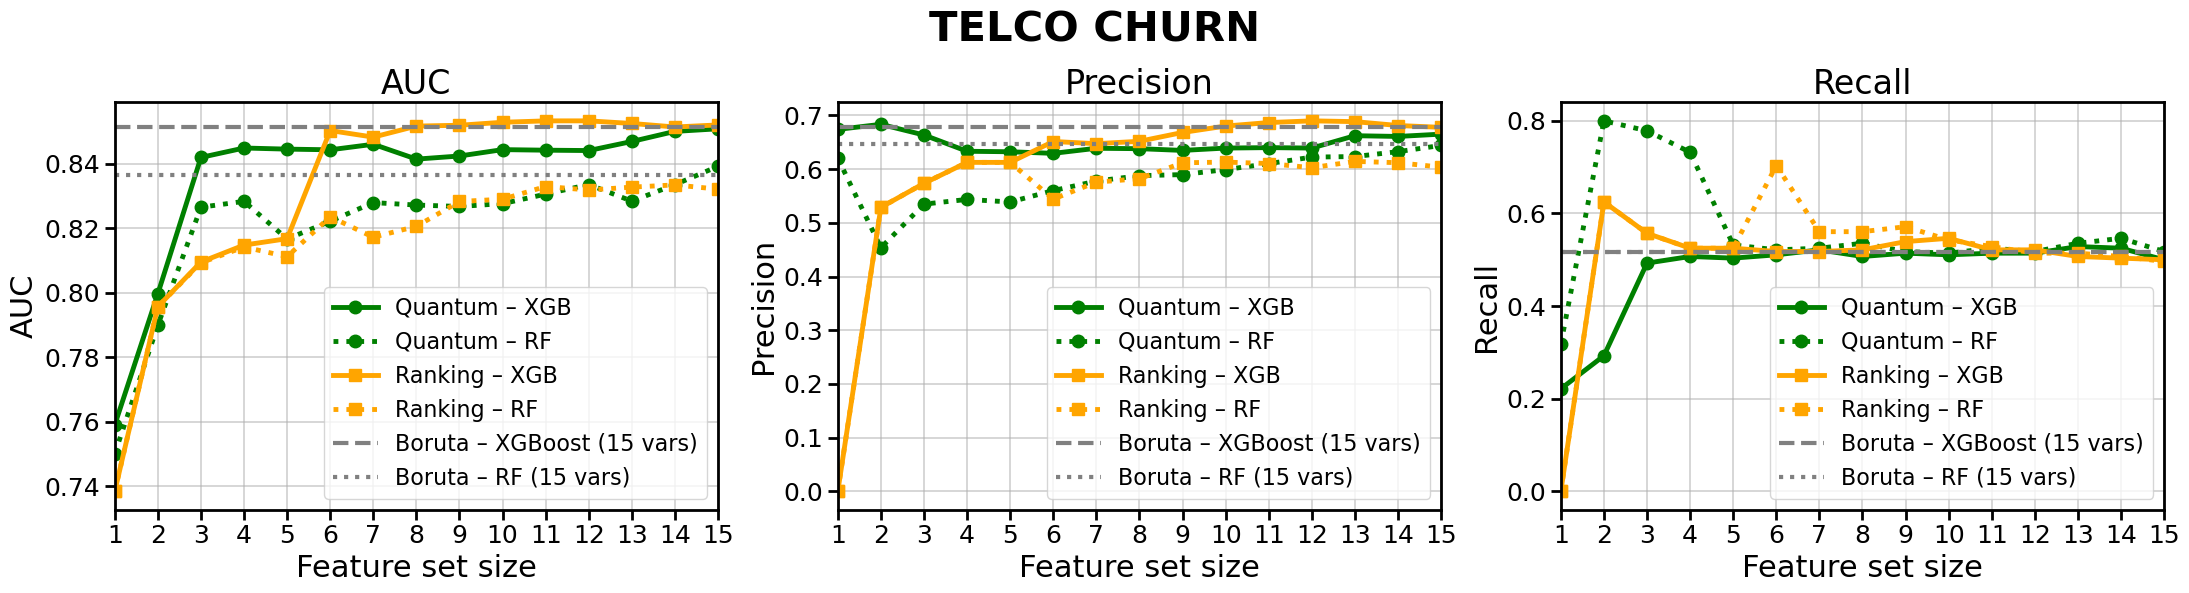

✅ PLOT STORED IN Results/CHURN/PLOT_Metrics_comparison_CHURN_subsets_XGB_vs_RF.png


'Results/CHURN/PLOT_Metrics_comparison_CHURN_subsets_XGB_vs_RF.png'

In [14]:
label = 'CHURN'

plot_metrics_combined_two_csvs_2(
    path_dir=f"Results/{label}",
    title = 'TELCO CHURN',
    csv_xgb=f"Metrics_comparison_{label}_subsets.csv",
    csv_rf=f"Metrics_comparison_{label}_subsets_RF.csv",
    dataset_label=label)


### Coincidence plots

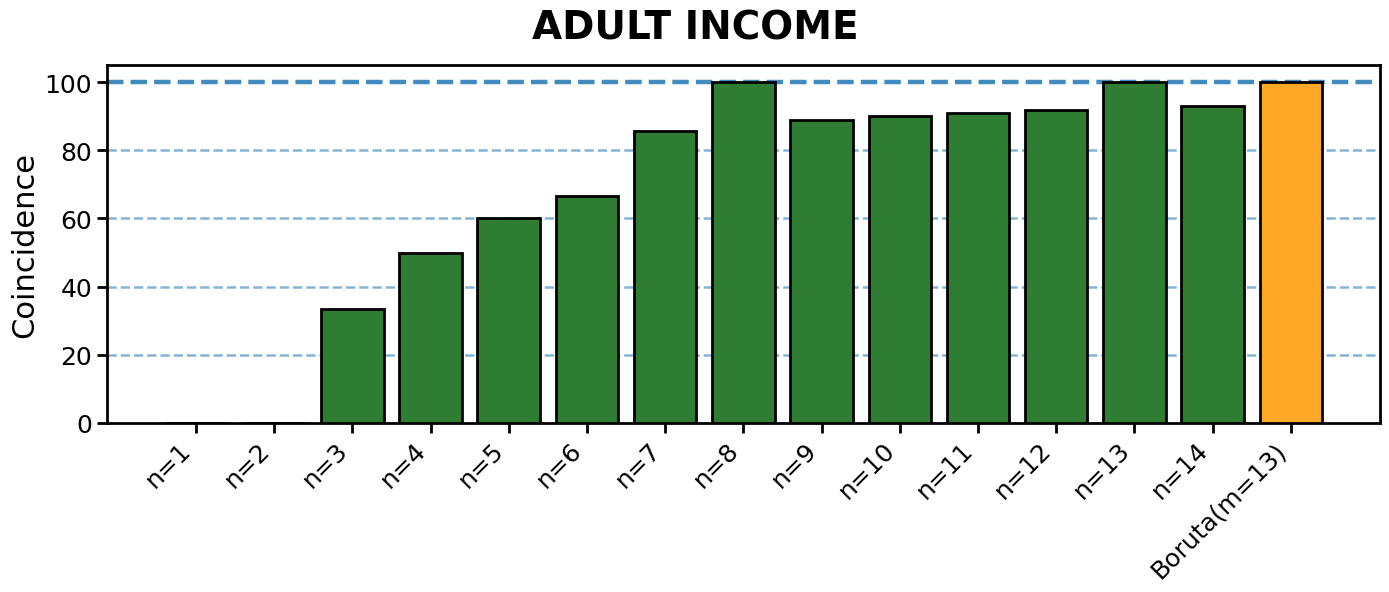

In [5]:
label = 'ADULT'

overlaps = plot_overlap_from_csv(f"Results/{label}/Metrics_comparison_{label}_subsets.csv", 'ADULT INCOME',
                                 save_path=f"Results/{label}/overlap_plot_{label}.png")
